In [26]:
#Import libraries
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

#### TThe code reads all FITS files in the folder, checks the value of IMAGETYP in the header, and classifies each image into bias, dark, flat, or light lists. Additionally, it organizes the dataset by creating separate directories for each image type. Also stores the file names and exposure times for later calibration process. 

In [27]:
folder = 'reduction_project/sample/'
base = 'reduction_project/'

for f in ['bias', 'dark', 'flat', 'science','products']:
    os.makedirs(base + f, exist_ok=True)

bias, dark, flat, light = [], [], [], []
bias_names, dark_names, flat_names, light_names = [], [], [], []
dark_exptime, flat_exptime, light_exptime = [], [], []

names = [f for f in os.listdir(folder) if f.endswith('.fit')]

for x in names:

    with fits.open(folder + x) as hdul:

        data = hdul[0].data
        header = hdul[0].header
        imagetype = header.get('IMAGETYP', 'UNKNOWN')

        if imagetype == 'Bias Frame':
            bias.append(data)
            bias_names.append(x)
            shutil.copy(folder + x, base + 'bias/' + x)

        elif imagetype == 'Dark Frame':
            dark.append(data)
            dark_names.append(x)
            dark_exptime.append(header['EXPTIME'])
            shutil.copy(folder + x, base + 'dark/' + x)

        elif imagetype == 'Flat Field':
            flat.append(data)
            flat_names.append(x)
            flat_exptime.append(header['EXPTIME'])
            shutil.copy(folder + x, base + 'flat/' + x)

        elif imagetype == 'Light Frame':
            light.append(data)
            light_names.append(x)
            light_exptime.append(header['EXPTIME'])
            shutil.copy(folder + x, base + 'science/' + x)

# Bias and Master Bias construction
#### A bias frame is a CCD image taken with zero exposure time and the shutter closed, so no light reaches the detector. It records only the electronic offset introduced during the readout process. Bias frames are used to measure and remove this constant electronic offset from all images during the calibration process.

#### This part of the code creates multiple histograms to visualize the distribution of pixel values (ADU) for each bias frame. To avoid the influence of outliers or inconsistent values, the histogram range is limited to the 1–99 percentiles of the data.

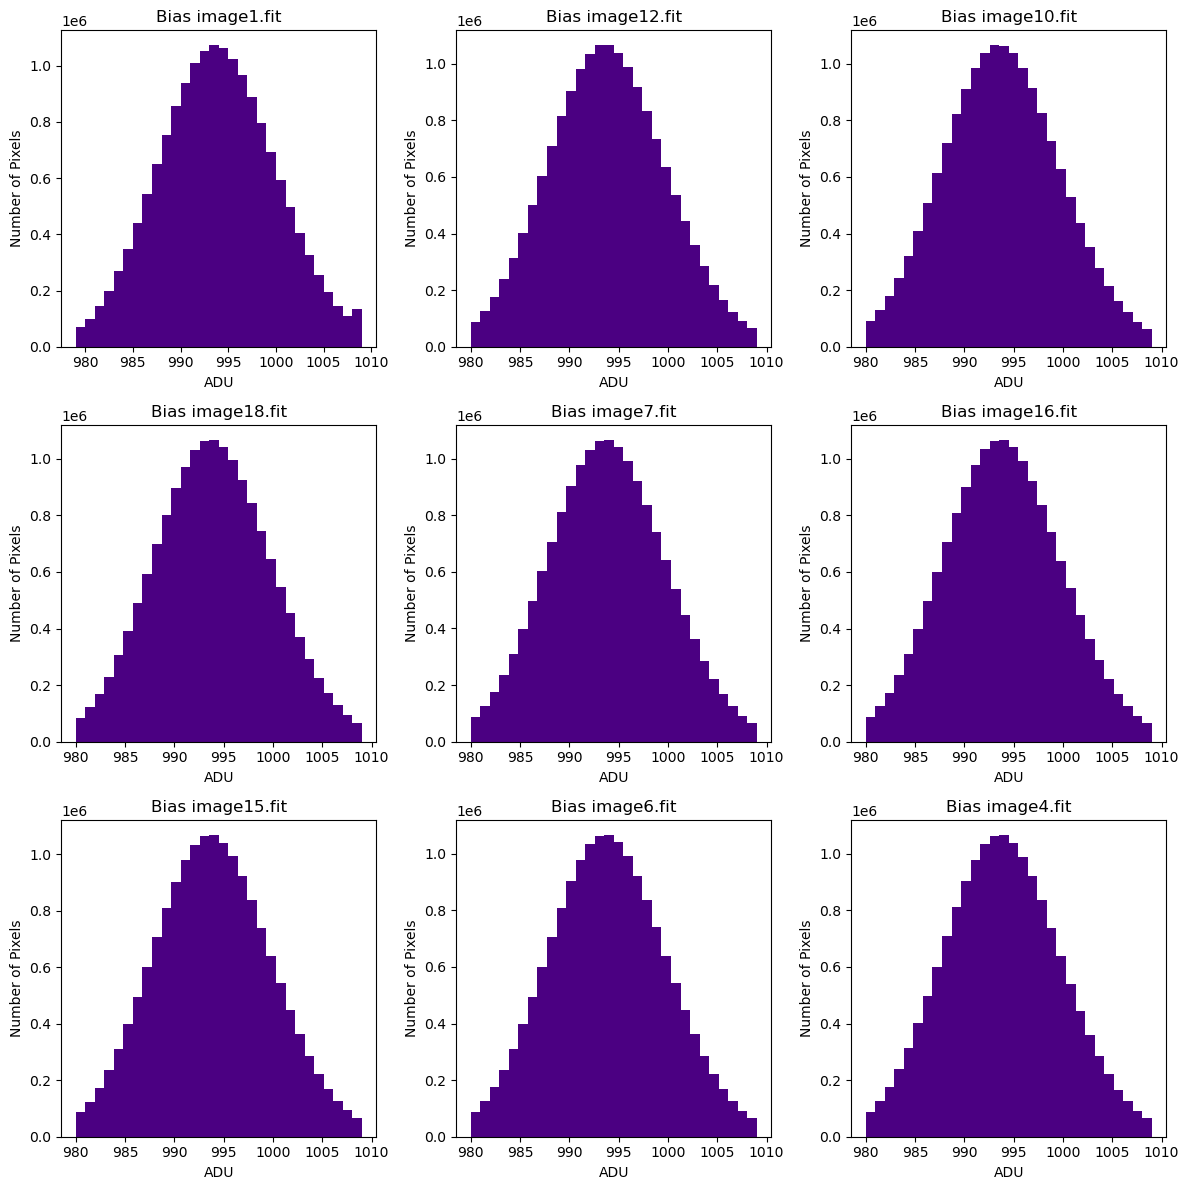

In [28]:
#plot config
bias_n = len(bias)
bias_cols = 3
bias_rows = int(np.ceil(bias_n / bias_cols))
bias_fig, bias_axes = plt.subplots(bias_rows, bias_cols, figsize=(12, 4*bias_rows))
bias_axes = bias_axes.flatten()

#histogram config
for i in range(bias_n):

    bias_range = np.percentile(bias[i], [1, 99])

    bias_axes[i].hist(bias[i].ravel(), bins=30, range=(bias_range[0], bias_range[1]), color='indigo')

    bias_axes[i].set_title('Bias ' + bias_names[i])
    bias_axes[i].set_xlabel('ADU')
    bias_axes[i].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.show()

#### The histograms show the distribution of pixel values (ADU) in each bias frame. The roughly Gaussian shape indicates that the variations are dominated by read noise, the random electronic noise introduced during the CCD readout process.

#### The bias frames were combined to create a Master Bias.  I chose the median method because it is more efficient against outliers and possible anomalous pixels, allowing a better estimate of the true bias level while reducing random noise.

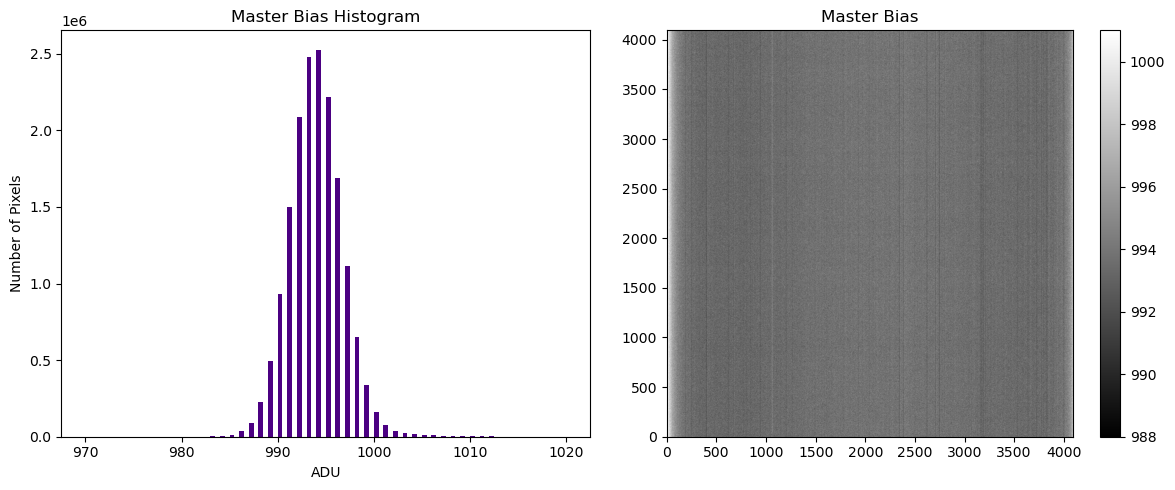

Mean Master Bias: 993.773767709732 ADU
Std Master Bias: 2.795034052925691 ADU


In [29]:
#obtain master bias by median method. Define value of the interval, mean and std of the master bias
master_bias = np.median(bias, axis=0)
mb_range = np.percentile(master_bias, [1, 99])
mb_mean = np.mean(master_bias)
mb_std = np.std(master_bias)

#histogram config
fig_mb, ax_mb = plt.subplots(1, 2, figsize=(12,5))
ax_mb[0].hist(master_bias.flatten(), bins=100, range=(970,1020), color='indigo')
ax_mb[0].set_title('Master Bias Histogram')
ax_mb[0].set_xlabel('ADU')
ax_mb[0].set_ylabel('Number of Pixels')

#image config
im_mb = ax_mb[1].imshow(master_bias, cmap='gray', origin='lower', vmin=mb_range[0], vmax=mb_range[1])
ax_mb[1].set_title('Master Bias')
fig_mb.colorbar(im_mb, ax=ax_mb[1])


plt.tight_layout()
plt.show()

print(f'Mean Master Bias: {mb_mean} ADU')
print(f'Std Master Bias: {mb_std} ADU')
fits.writeto(base + 'products/master_bias.fits', master_bias, overwrite=True)

#### As observed, the majority of outliers were eliminated, maintaining a clear Gaussian distribution. This confirms that the Master Bias construction successfully reduced random read noise, yielding consistent values for the mean and standard deviation.
#### The image shows the two dimensional distribution of the Master Bias across the CCD, appearing mainly as faint vertical patterns produced by the detector electronics.

# Dark Frames and Master Dark construction
#### A dark frame is a CCD image taken with the shutter closed and a non-zero exposure time. It measures the thermal signal and hot pixels so this contribution can be substracted during calibration.

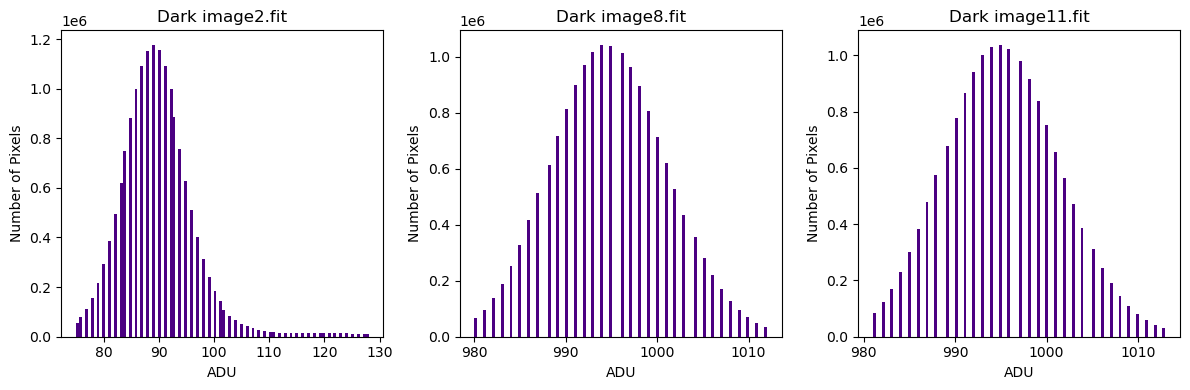

image2.fit Exposure time : 200.0 s CCD Temperature -15.8 °C
image8.fit Exposure time : 180.0 s CCD Temperature -25.0 °C
image11.fit Exposure time : 240.0 s CCD Temperature -25.0 °C


In [30]:
#plot config
dark_n = len(dark)
darkcols = 3
darkrows = int(np.ceil(dark_n/darkcols))

darkfig, darkaxes = plt.subplots(darkrows, darkcols, figsize=(12, 4*darkrows))
darkaxes = darkaxes.flatten()
#histogram for dark frames
for v in range(dark_n):
    darkaxes[v].hist(dark[v].flatten(), bins=100, range=np.percentile(dark[v],[1,99]), color='indigo')
    darkaxes[v].set_title('Dark ' + dark_names[v])
    darkaxes[v].set_xlabel('ADU')
    darkaxes[v].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.show()
#print exposure time and temperature to see the reason of anomalous adu
for i in range(len(dark_names)):
    with fits.open(folder + dark_names[i]) as hdul:
        print(dark_names[i],'Exposure time :',hdul[0].header['EXPTIME'],'s','CCD Temperature', hdul[0].header['CCD-TEMP'],'°C')

#### The dark frame 'image2.fit' was excluded from the Master Dark creation due to anomalies in its header. The header recorded a CCD temperature significantly higher than the stable temperature of the other frames. This thermal difference caused an anomalous ADU distribution and a pronounced tail of hot pixels.

#### The Master Dark was constructed by combining the dark frames after substractic the Master Bias and normalizing  each frame by its exposure time with the equation:

$$ \text{Masted Dark} = \text{Combination} \left( \frac{\text{Dark}_i-\text{Master Bias}}{\text{EXPTIME}_{Dark_i}}\right) $$

#### The exposure time is required to convert the accumulated thermal signal into a dark current rate **[ADU/s]**, allowing the thermal noise contribution to be properly quantified per unit time.

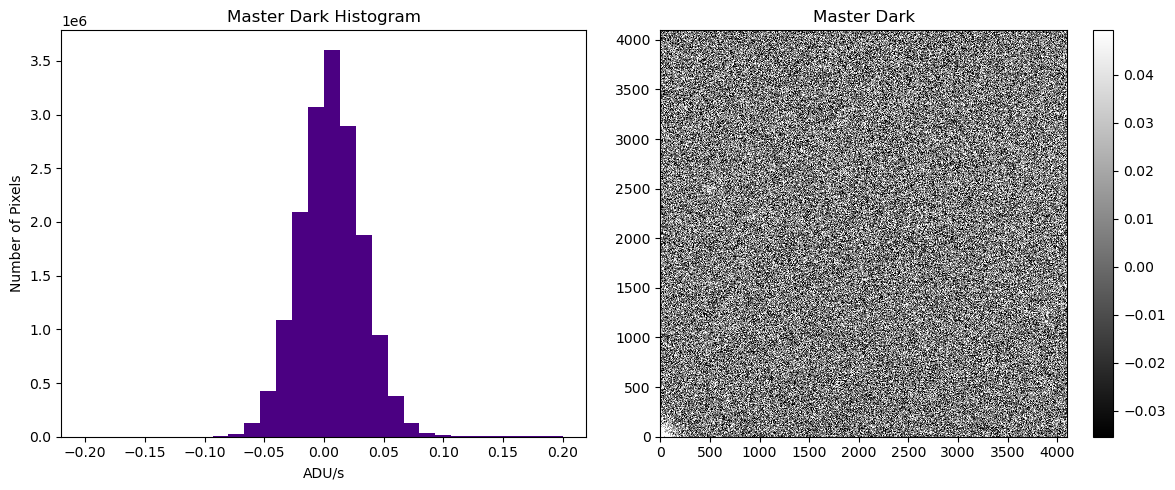

Mean Master Dark: 0.009170042516456697 ADU/s
Std Master Dark: 0.29299984518602 ADU/s


In [31]:
#master dark calculation method
dark_corrected = []
for i in range(1, len(dark)):
    dark_i = (dark[i] - master_bias) / dark_exptime[i]
    dark_corrected.append(dark_i)

combination = np.array(dark_corrected)
master_dark = np.median(combination, axis=0)
md_range = np.percentile(master_dark,[5,95])
md_mean = np.mean(master_dark) 
md_std = np.std(master_dark)

#histogram config
fig_md, ax_md = plt.subplots(1,2, figsize=(12,5))
ax_md[0].hist(master_dark.ravel(), bins=30, range=(-0.2,0.2), color='indigo')

ax_md[0].set_title('Master Dark Histogram')
ax_md[0].set_xlabel('ADU/s')
ax_md[0].set_ylabel('Number of Pixels')

#image config
im_md = ax_md[1].imshow(master_dark, cmap='grey', vmin=md_range[0], vmax=md_range[1], interpolation='none', origin = 'lower')
ax_md[1].set_title('Master Dark')
fig_md.colorbar(im_md, ax=ax_md[1])

plt.tight_layout()
plt.show()
print(f'Mean Master Dark: {md_mean} ADU/s')
print(f'Std Master Dark: {md_std} ADU/s')
fits.writeto(base + 'products/master_dark.fits', master_dark, overwrite=True)


#### The mean of the distribution provides an estimate of the average number of ADUs generated per second per pixel due to the CCD dark current. The standard deviation quantifies the dispersion of the pixel values around the mean and characterizes the noise associated with the dark signal. The image was displayed using ''interpolation = 'none' '' to avoid the smoothing applied by Matplotlib during image rendering. Disabling it ensures that each pixels is shown exactly as recorded.

# Flat Field and Master Flat construction

#### Flat field exposures are calibration frames used to correct for pixel-to-pixel sensitivity variations and non-uniform illumination across the CCD detector. They are obtained by imaging a uniformly illuminated folder, such as the twilight sky or a dome screen. Multiple flats are typically combined to create a master flat used for image calibration.

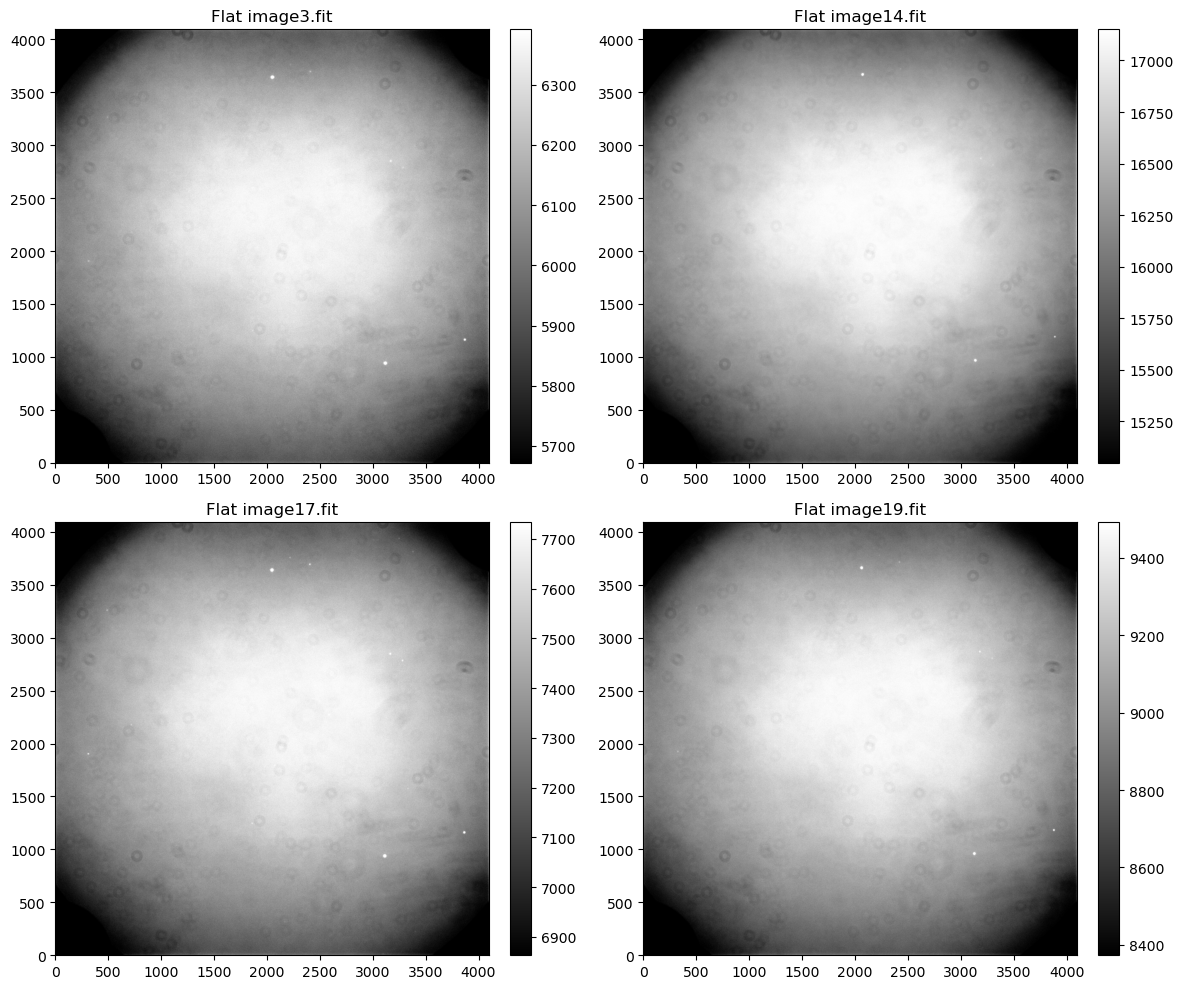

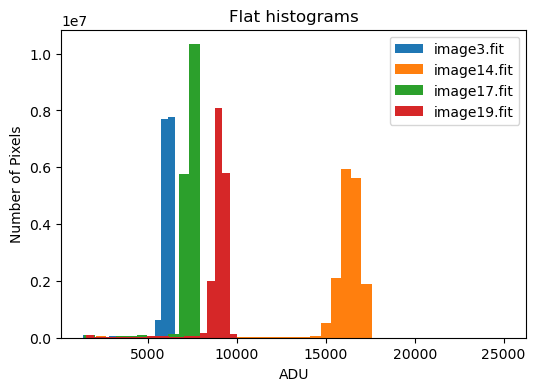

image3.fit Exposure time : 5.0 s Filter : sloan_r
image14.fit Exposure time : 5.0 s Filter : sloan_r
image17.fit Exposure time : 10.0 s Filter : sloan_r
image19.fit Exposure time : 5.0 s Filter : sloan_r


In [32]:
#plot config
flat_n = len(flat)
fig_flat_img, axes_flat_img = plt.subplots(2, 2, figsize=(12, 10))
axes_flat_img = axes_flat_img.flatten()

#image config
for i in range(flat_n):
    flat_range = np.percentile(flat[i], [5,95])
    im =axes_flat_img[i].imshow(flat[i], cmap='gray', vmin=flat_range[0], vmax=flat_range[1], origin = 'lower')
    axes_flat_img[i].set_title('Flat ' + flat_names[i])
    cbar = fig_flat_img.colorbar(im, ax=axes_flat_img[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
plt.figure(figsize=(6,4))

#histogram all flat fields in the same plot
for i in range(len(flat)):
    plt.hist(flat[i].flatten(), bins=40, label=flat_names[i])

plt.xlabel('ADU')
plt.ylabel('Number of Pixels')
plt.title('Flat histograms')
plt.legend()

plt.show()
#print information about filters and exposure time
for i in range(len(flat_names)):
    with fits.open(folder + flat_names[i]) as hdul:
        print(flat_names[i], 'Exposure time :', hdul[0].header['EXPTIME'], 's', 'Filter :', hdul[0].header['FILTER'])

#### The flat images show instrumental features such as vignetting (darker edges) and dust artifacts appearing as faint circular patterns. These effects originate from the optical system and detector and are the variations that flat field calibration is designed to correct. One flat shows a taller histogram peak with more concentrated pixels, but this is not problematic since all flats were taken with the same filter and represent the same instrumental pattern. Therefore, four flats are combined and normalized to construct the Normalized Master Flat.

#### Each flat was first corrected by subtracting the Master Bias and the scaled Master Dark according to its exposure time. The corrected flats were then normalized by dividing by their mean value to remove differences in illumination or exposure time.

$$ \text{Master Flat} =  \text{Combination of} \frac{\text{Flat}_i - \text{Master Bias} - \text{Master Dark}\cdot \text{EXPTIME}_{\text{FLAT}_i}}{\text{Median or mean}}$$

#### The normalized flats were combined using the median to create the Normalized Master Flat, since the median is robust against outliers. A histogram of the Master Flat was then used to estimate its mean and standard deviation.

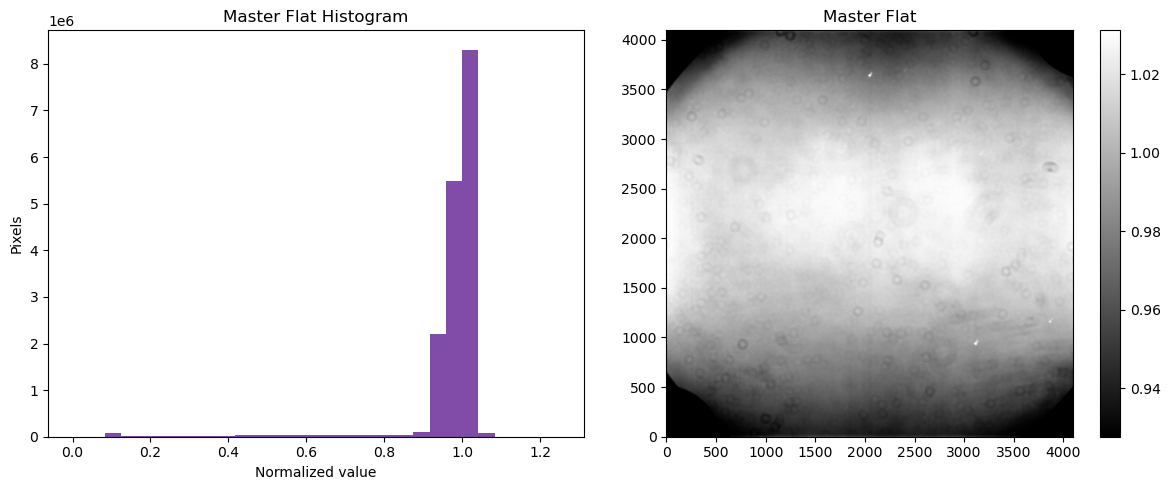

Mean: 0.9765477870600878
Std: 0.10899569386303878


In [33]:
#Master flat calculation: correction, normalization and masterflat normalization
flat_norm = []
for i in range(len(flat)):
    flat_corrected = flat[i] - master_bias - master_dark * flat_exptime[i]
    flat_normalized = flat_corrected / np.median(flat_corrected)
    flat_norm.append(flat_normalized)

flat_norm = np.array(flat_norm)
master_flat = np.median(flat_norm, axis=0)
master_flat_norm = master_flat / np.median(master_flat, axis=0)


mf_range = np.percentile(master_flat_norm, [5,95])

#histogram config
fig_mf, ax_mf = plt.subplots(1,2, figsize=(12,5))
ax_mf[0].hist(master_flat_norm.ravel(), bins=30, alpha=0.7, color='indigo', range= (0,1.25))
ax_mf[0].set_title('Master Flat Histogram')
ax_mf[0].set_xlabel('Normalized value')
ax_mf[0].set_ylabel('Pixels')

#image config
im_mf = ax_mf[1].imshow(master_flat_norm, cmap='gray', origin='lower', vmin=mf_range[0], vmax=mf_range[1])
ax_mf[1].set_title('Master Flat')
fig_mf.colorbar(im_mf, ax=ax_mf[1])

plt.tight_layout()
plt.show()

# mean and std
mf_mean = np.mean(master_flat_norm)
mf_std = np.std(master_flat_norm)

print('Mean:', mf_mean)
print('Std:', mf_std)
fits.writeto(base + 'products/master_flat.fits', master_flat, overwrite=True)

#### The corrected flats were then normalized by dividing each frame by its mean value, which removes differences in illumination level or exposure time between the flats.
#### The normalized flats were combined using the median to construct the Normalized Master Flat. The median was chosen because it is robust against outliers, although a few remain. The histogram distribution is centered around 1, as expected for a normalized flat. The Master Flat image shows vignetting and faint circular dust artifacts across the field, which will be corrected when the science images are processed.

# Reduce a Science Image

#### A science image was selected from the dataset, process the correction using the equation 
$$ \text{Image}_{\text{corrected}} = \frac{\text{Image}_{\text{raw}}-\text{Master Bias}-\text{Master Dark}\cdot \text{EXPTIME}_{\text{image}}}{\text{Normalized Master Flat}}$$ 

In [34]:
#information about science images
for i in range(len(light_names)):
    with fits.open(folder + light_names[i]) as hdul:
        print(light_names[i], 'Exposure time :', hdul[0].header['EXPTIME'], 's', 'Filter :', hdul[0].header['FILTER'])

image5.fit Exposure time : 100.0 s Filter : sloan_r
image13.fit Exposure time : 100.0 s Filter : sloan_r
image9.fit Exposure time : 100.0 s Filter : sloan_r


### The header of each science image was inspected to obtain the exposure time and the filter used during the observations, as this information is required for an optimal calibration process. By analyzing the raw science image using a histogram, the ADU distribution can be examined

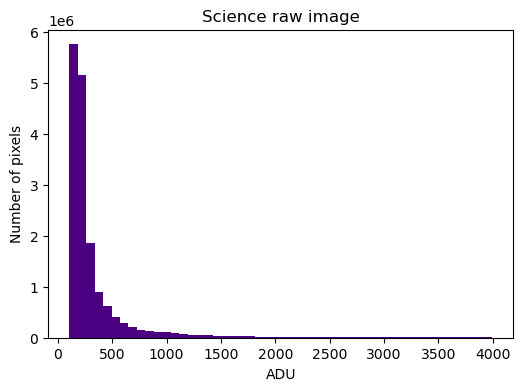

In [35]:
# science image selection and histogram
science = light[1]
exptime_science = light_exptime[1]

science_raw_range = np.percentile(science, [1, 99])

plt.figure(figsize=(6,4))
plt.hist(science.flatten(), bins=50, range=science_raw_range, color='indigo')

plt.xlabel('ADU')
plt.ylabel('Number of pixels')
plt.title('Science raw image')

plt.show()

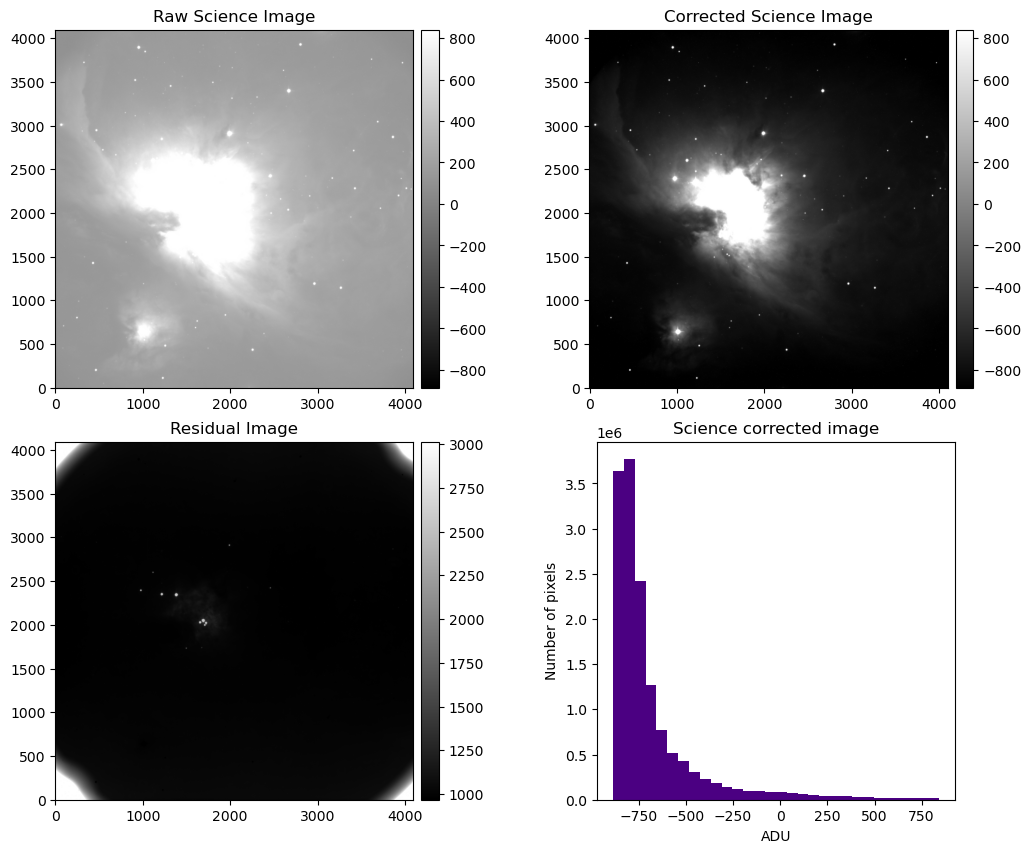

In [36]:
# raw and corrected calculation
science_corrected = (science - master_bias - master_dark * exptime_science) / master_flat_norm

# global range
combined = np.concatenate((science.flatten(), science_corrected.flatten()))
vmin = np.percentile(combined, 5)
vmax = np.percentile(combined, 95)

# residual calculations
residual = science - science_corrected
residual_range = np.percentile(residual, [1,99])

# plot config
fig_sc, ax_sc = plt.subplots(2, 2, figsize=(12,10))

# raw config
im1 = ax_sc[0,0].imshow(science, cmap='gray', vmin=vmin, vmax=vmax, origin='lower', aspect='equal')
ax_sc[0,0].set_title('Raw Science Image')
fig_sc.colorbar(im1, ax=ax_sc[0,0], fraction=0.046, pad=0.02)

# corrected config
im2 = ax_sc[0,1].imshow(science_corrected, cmap='gray', vmin=vmin, vmax=vmax, origin='lower', aspect='equal')
ax_sc[0,1].set_title('Corrected Science Image')
fig_sc.colorbar(im2, ax=ax_sc[0,1], fraction=0.046, pad=0.02)

# residual config
im3 = ax_sc[1,0].imshow(residual, cmap='gray', vmin=residual_range[0], vmax=residual_range[1], origin='lower', aspect='equal')
ax_sc[1,0].set_title('Residual Image')
fig_sc.colorbar(im3, ax=ax_sc[1,0], fraction=0.046, pad=0.02)

# histogram config
ax_sc[1,1].hist(science_corrected.flatten(), bins=30, color='indigo', range=(vmin, vmax))
ax_sc[1,1].set_title('Science corrected image')
ax_sc[1,1].set_xlabel('ADU')
ax_sc[1,1].set_ylabel('Number of pixels')
ax_sc[1,1].set_box_aspect(1)

plt.subplots_adjust(hspace=0.15, wspace=0.35)
plt.show()
fits.writeto(base + 'products/science_corrected.fits', science_corrected, overwrite=True)
fits.writeto(base + 'products/residual.fits', residual, overwrite=True)

#### The raw science histogram shows a peculiar distribution, where most pixels correspond to the sky background at low ADU values. 
#### Comparing the raw and corrected images, the calibration process, subtracting the master bias and the master dark with the exposure time and dividing by the normalized master flat removes most instrumental effects. The raw image shows bright points that can correspond to stars or hot pixels and a less uniform background. 
#### In the corrected image, the background becomes smoother as bias level, dark current, viggneting and dust features are removed. The residual image shows the structures removed during the calibration process. However, due to saturation in the detector, the reduction is limited and some regions cannot be fully corrected.

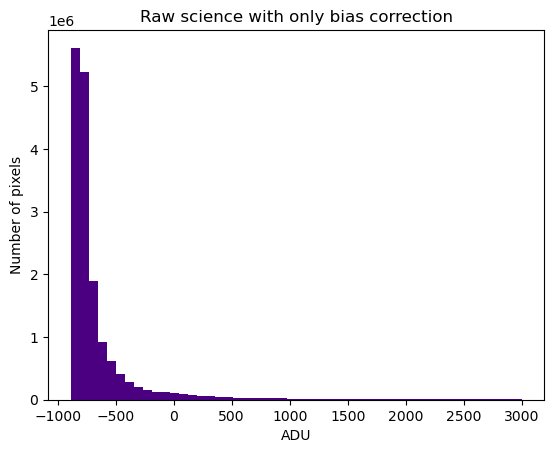

In [38]:
#Raw science and Master bias analysis 
science_bias = science - master_bias
plt.hist(science_bias.flatten(), bins = 50, color='indigo', range= np.percentile(science_bias,[1,99]));
plt.title('Raw science with only bias correction')
plt.xlabel('ADU')
plt.ylabel('Number of pixels');

#### The main contribution to the displacement of ADU values into negative are from the subtraction of the master bias, wich removes an electronic offset of approximately 993 ADU (mean value).  Additionally, it is important to consider visualization effects when interpreting the images. Matplotlib automatically rescales the colorbar for each image independently, which can exaggerate visual differences between the raw and corrected images.

## What type of astronomical object is present in the image?

#### The image shows a large cloud of molecular gas and dust where new stars are forming. After the calibration process, the central region appears brighter and more prominent, which may be associated with recently formed massive stars, such as O- and B-type stars, that strongly ionize the surrounding gas. By checking the coordinates provided in the FITS header, the object in the field can be identified as the Orion Nebula(M42), one of the closest and known star forming regions in our galaxy.